# Task 2 - Unsupervised Domain Adaptation

PACS Source-only, DAN, DANN, and CDAN under the specified transductive protocol.

**Execution policy:** this notebook is intentionally delivered unexecuted. Set the configuration paths and switches, then run top-to-bottom when you are ready to conduct the experiment. It does not answer the report questions.

## 1. Configuration and protocol

This notebook uses PACS sources Photo/Art Painting/Cartoon and unlabeled Sketch. Do not inspect target-label metrics until `final_evaluation` at the end.

The next cell fixes the PACS protocol, source/target batch composition, optimization budget, main MMD setting, and the controlled-study values. It produces no metrics.

In Colab, this configuration mounts Drive. Large inputs and checkpoints live under `ATML_PA1/` in Drive; small final outputs go to this task's repository `results/` directory. The repository name is detected automatically.

In [1]:
# Standard library and experiment dependencies.
# Install dependencies yourself before executing: torch torchvision open_clip_torch
# scikit-learn pandas matplotlib seaborn pillow scipy tqdm
import json, random, math, copy
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms
from torchvision.transforms import InterpolationMode

from datasets import load_dataset
from tqdm.auto import tqdm

SEED = 6304
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### Repository and Drive paths

The next cell locates the clone, mounts Drive in Colab, and creates persistent data/checkpoint/artifact directories plus the task's small-results directory.

In [2]:
# The clone holds code and small final outputs; Drive retains large inputs and models.

REPO_ROOT = Path('/content/atml-pa1')
TASK_ROOT = REPO_ROOT / "task2"
REPO_RESULTS_DIR = TASK_ROOT / "results"

import os

if "COLAB_RELEASE_TAG" in os.environ:
    from google.colab import drive

    drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/ATML_PA1")
DATA_ROOT = DRIVE_ROOT / "data"
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints" / "task2"
ARTIFACT_DIR = DRIVE_ROOT / "artifacts" / "task2"
EXTERNAL_DIR = DRIVE_ROOT / "external"
TORCH_CACHE_DIR = EXTERNAL_DIR / "torch_cache"
HF_CACHE_DIR = EXTERNAL_DIR / "huggingface_cache"

for directory in (
    REPO_RESULTS_DIR,
    DATA_ROOT,
    CHECKPOINT_DIR,
    ARTIFACT_DIR,
    EXTERNAL_DIR,
    TORCH_CACHE_DIR,
    HF_CACHE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

# Pretrained-weight downloads also survive a Colab runtime reset.
os.environ["TORCH_HOME"] = str(TORCH_CACHE_DIR)
os.environ["HF_HOME"] = str(HF_CACHE_DIR)


Mounted at /content/drive


### Reproducibility and display helpers

The next cell defines the fixed-seed behavior and small output helpers. It does not run an experiment.

In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def save_json(value, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(value, f, indent=2)


def show_table(rows, title=None):
    frame = pd.DataFrame(rows)
    if title:
        print(title)
    display(frame)
    return frame


set_seed()


### Task settings

The next cell records this task's data path, fixed experiment settings, and plot/print_metrics switches. It produces no metrics.

In [4]:
from torchvision.models import resnet18, ResNet18_Weights

CONFIG = {
    "pacs_root": DATA_ROOT / "PACS",
    "results_dir": REPO_RESULTS_DIR,
    "batch_size_per_domain": 8,
    "target_batch_size": 24,
    "epochs": 30,
    "patience": 5,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "mmd_lambda": 1.0,
    "study_lambdas": [0.1, 1.0, 10.0],
    "plot": True,
    "print_metrics": True,
}
SOURCES = ["photo", "art_painting", "cartoon"]
TARGET = "sketch"
CLASSES = ["dog", "elephant", "giraffe", "guitar", "horse", "house", "person"]
RESULTS = Path(CONFIG["results_dir"])
RESULTS.mkdir(parents=True, exist_ok=True)


### Download PACS

In [5]:

PACS_ROOT = DATA_ROOT / "PACS"

ds = load_dataset("flwrlabs/pacs", split="train")
class_names = ds.features["label"].names

for i, row in enumerate(tqdm(ds, total=len(ds))):
    domain = row["domain"]
    class_name = class_names[row["label"]]

    folder = PACS_ROOT / domain / class_name
    folder.mkdir(parents=True, exist_ok=True)

    image_path = folder / f"{i:05d}.jpg"

    if image_path.exists():
        continue

    row["image"].convert("RGB").save(image_path)

print("Finished:", sum(1 for _ in PACS_ROOT.rglob("*.jpg")))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  191MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9991 [00:00<?, ? examples/s]

  0%|          | 0/9991 [00:00<?, ?it/s]

Finished: 9991


## 2. PACS indexing, fixed source splits, transforms, and frozen BatchNorm statistics

The next cell indexes PACS, writes the shared deterministic source split for Task 3, sets the prescribed augmentations, and defines the frozen-BatchNorm ResNet-18.

In [6]:
# Expected PACS layout: PACS/<domain>/<class>/*.jpg. The JSON split is shared with Task 3.

def index_pacs(root, domains):
    rows = []
    for domain in domains:
        for label, name in enumerate(CLASSES):
            for path in sorted((root / domain / name).glob("*")):
                rows.append({"path": str(path), "domain": domain, "label": label})
    return pd.DataFrame(rows)


for domain in SOURCES:
    domain_dir = CONFIG["pacs_root"] / domain
    if not domain_dir.is_dir():
        raise FileNotFoundError(f"PACS source domain is missing from Google Drive: {domain_dir}")
    
all_source = index_pacs(CONFIG["pacs_root"], SOURCES)
target_dir = CONFIG["pacs_root"] / TARGET
if not target_dir.is_dir():
    raise FileNotFoundError(f"PACS unlabeled target domain is missing from Google Drive: {target_dir}")

target_index = index_pacs(CONFIG["pacs_root"], [TARGET])
rng = np.random.default_rng(SEED)

split_rows = []
# Split within each source-domain/class group so both class balance and domain identity are preserved.
for (domain, label), group in all_source.groupby(["domain", "label"]):
    ids = group.index.to_numpy().copy()
    rng.shuffle(ids)
    cut = int(0.8 * len(ids))
    for position, image_index in enumerate(ids):
        split_name = "train" if position < cut else "val"
        split_rows.append({"index": int(image_index), "split": split_name})
splits = pd.DataFrame(split_rows).set_index("index")
all_source = all_source.join(splits)

save_json(
    all_source.reset_index().to_dict("records"),
    REPO_ROOT / "common" / "splits" / "pacs_sketch_seed6304.json",
)


### PACS transforms and ResNet-18 setup

The fixed source split above is saved for Task 3. The following code defines training/evaluation transforms and the shared model without reading target labels for selection.

In [7]:
weights = ResNet18_Weights.IMAGENET1K_V1
train_tf = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(weights.transforms().mean, weights.transforms().std),
    ]
)
eval_tf = transforms.Compose(
    [
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(weights.transforms().mean, weights.transforms().std),
    ]
)


class PACSDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        return self.transform(Image.open(row.path).convert("RGB")), int(row.label), row.domain


# Keep pretrained running moments fixed; gamma and beta remain trainable parameters.
def freeze_bn_statistics(model):
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


def make_model():
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 7)
    return model.to(DEVICE)


## 3. Shared losses and training utilities

The next cell defines MMD, gradient reversal, the domain discriminator, 512-dimensional feature extraction, domain-balanced loaders, and accuracy/macro-F1 evaluation helpers.

In [8]:
# RBF MMD compares source and target feature distributions without target labels.
def gaussian_mmd(source, target):
    joined = torch.cat([source, target])
    distances = torch.cdist(joined, joined).pow(2)
    median = distances[distances > 0].median().detach().clamp_min(1e-6)
    # Keep all three prescribed bandwidths; each contributes to the same MMD estimate.
    kernels = 0
    for scale in (0.5, 1.0, 2.0):
        kernels = kernels + torch.exp(-distances / (2 * (scale * median)))
    n = len(source)
    m = len(target)
    return kernels[:n, :n].mean() + kernels[n:, n:].mean() - 2 * kernels[:n, n:].mean()


class GradientReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad):
        return -ctx.alpha * grad, None


def grl(x, alpha):
    return GradientReverse.apply(x, alpha)


class DomainDiscriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 2)
        )

    def forward(self, x, alpha):
        return self.net(grl(x, alpha))


# The feature tensor has shape [batch, 512], immediately before the seven-class classifier.
def features_and_logits(model, x):
    # Mirror ResNet's forward pass, while retaining the 512-D vector before fc.
    h = model.maxpool(model.relu(model.bn1(model.conv1(x))))
    h = model.layer1(h)
    h = model.layer2(h)
    h = model.layer3(h)
    h = model.layer4(h)
    feature = torch.flatten(model.avgpool(h), 1)
    return feature, model.fc(feature)


def domain_loaders(frame, split, transform):
    loaders = {}
    for domain in SOURCES:
        selected = frame[(frame.domain == domain) & (frame.split == split)]
        dataset = PACSDataset(selected, transform)
        loaders[domain] = DataLoader(
            dataset,
            batch_size=CONFIG["batch_size_per_domain"],
            shuffle=True,
            drop_last=True,
        )
    return loaders


def evaluate(model, frame, transform=eval_tf):
    model.eval()
    freeze_bn_statistics(model)
    ys = []
    ps = []
    for x, y, _ in DataLoader(PACSDataset(frame, transform), batch_size=64):
        with torch.no_grad():
            _, z = features_and_logits(model, x.to(DEVICE))
            ps.extend(z.argmax(1).cpu())
            ys.extend(y)
    return {
        "accuracy": accuracy_score(ys, ps),
        "macro_f1": f1_score(ys, ps, average="macro"),
        "y": np.array(ys),
        "pred": np.array(ps),
    }


## 4. Source-only, DAN, DANN, and CDAN

Each method uses domain-balanced source batches plus 24 unlabeled target images. Checkpoint selection uses only mean source-validation macro-F1.

The next cell trains Source-only, DAN, DANN, and CDAN with a common pipeline. It records classification/alignment losses and uses only mean source-validation macro-F1 to select checkpoints.

In [9]:
# Target labels are never read here; they cannot influence gradients or checkpoint selection.
def train_method(method, alignment_strength=1.0):
    set_seed()
    model = make_model()
    discriminator = None
    disc_dim = 512 if method == "dann" else 512 * 7
    # Gradient reversal trains the discriminator normally while reversing only its gradient into the backbone.
    if method in {"dann", "cdan"}:
        discriminator = DomainDiscriminator(disc_dim).to(DEVICE)
    trainable_parameters = list(model.parameters())
    if discriminator is not None:
        trainable_parameters += list(discriminator.parameters())
    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )
    source_iters = {
        d: iter(loader) for d, loader in domain_loaders(all_source, "train", train_tf).items()
    }
    # Source-only ERM must not load Sketch at all. Adaptation methods receive images only,
    # never target labels, through this separate loader.
    target_loader = None
    target_iter = None
    if method != "source_only":
        target_loader = DataLoader(
            PACSDataset(target_index.assign(split="target"), train_tf),
            batch_size=CONFIG["target_batch_size"],
            shuffle=True,
            drop_last=True,
        )
        target_iter = iter(target_loader)
    best, best_state, stale, history = -1, None, 0, []
    for epoch in range(CONFIG["epochs"]):
        model.train()
        freeze_bn_statistics(model)
        total_cls = total_align = 0
        # Use the longest source loader as the epoch budget; shorter domains cycle.
        steps = max(
            len(loader) for loader in domain_loaders(all_source, "train", train_tf).values()
        )
        for step in range(steps):
            source_batches = []
            for d in SOURCES:
                try:
                    batch = next(source_iters[d])
                except StopIteration:
                    source_iters[d] = iter(domain_loaders(all_source, "train", train_tf)[d])
                    batch = next(source_iters[d])
                source_batches.append(batch)
            sx = torch.cat([b[0] for b in source_batches]).to(DEVICE)
            sy = torch.cat([b[1] for b in source_batches]).to(DEVICE)
            sf, sz = features_and_logits(model, sx)
            tf = None
            if method != "source_only":
                try:
                    target_batch = next(target_iter)
                except StopIteration:
                    target_iter = iter(target_loader)
                    target_batch = next(target_iter)
                # The target batch contains labels in the dataset object, but this code reads only images.
                tx = target_batch[0].to(DEVICE)
                tf, _ = features_and_logits(model, tx)
            cls = F.cross_entropy(sz, sy)
            align = torch.zeros((), device=DEVICE)
            if method == "dan":
                align = alignment_strength * gaussian_mmd(sf, tf)
            if method in {"dann", "cdan"}:
                progress = (epoch * steps + step) / (CONFIG["epochs"] * steps)
                alpha = 2 / (1 + math.exp(-10 * progress)) - 1
                if method == "cdan":
                    # Outer products turn [B, 512] features and [B, 7] probabilities into [B, 3584].
                    sf_in = torch.einsum("bi,bj->bij", sf, F.softmax(sz, 1)).flatten(1)
                    tf_logits = features_and_logits(model, tx)[1]
                    tf_in = torch.einsum("bi,bj->bij", tf, F.softmax(tf_logits, 1)).flatten(1)
                else:
                    sf_in, tf_in = sf, tf
                domain_logits = discriminator(torch.cat([sf_in, tf_in]), alpha)
                domain_labels = torch.cat(
                    [torch.zeros(len(sf), dtype=torch.long), torch.ones(len(tf), dtype=torch.long)]
                ).to(DEVICE)
                align = F.cross_entropy(domain_logits, domain_labels)
            optimizer.zero_grad()
            (cls + align).backward()
            optimizer.step()
            total_cls += cls.item()
            total_align += align.item()
            
        val_scores = []
        for domain in SOURCES:
            validation_rows = all_source[
                (all_source.domain == domain) & (all_source.split == "val")
            ]
            validation_metrics = evaluate(model, validation_rows)
            val_scores.append(validation_metrics["macro_f1"])
        # Target labels never choose a checkpoint.
        score = float(np.mean(val_scores))
        history.append(
            {
                "epoch": epoch + 1,
                "classification_loss": total_cls / steps,
                "alignment_or_domain_loss": total_align / steps,
                "mean_source_val_f1": score,
            }
        )
        if score > best:
            best = score
            stale = 0
            discriminator_state = None
            if discriminator is not None:
                discriminator_state = copy.deepcopy(discriminator.state_dict())
            best_state = {
                "model": copy.deepcopy(model.state_dict()),
                "disc": discriminator_state,
            }
        else:
            stale += 1
        if stale >= CONFIG["patience"]:
            break
    model.load_state_dict(best_state["model"])
    return model, history


### Train the four adaptation methods

The following cell runs Source-only, DAN, DANN, and CDAN in the existing order, then saves the selected Source-only checkpoint to Drive for Task 3.

In [10]:
models_by_method = {}
histories = {}
for method in ["source_only", "dan", "dann", "cdan"]:
    models_by_method[method], histories[method] = train_method(method, CONFIG["mmd_lambda"])

# Task 3 must reuse this exact ERM baseline rather than retraining it.
for method, model in models_by_method.items():
    torch.save(
        {"model": model.state_dict()},
        CHECKPOINT_DIR / f"{method}.pt"
    )


### Loading models (if saved after training)

In [ ]:
models_by_method = {}

for method in ["source_only", "dan", "dann", "cdan"]:
    model = make_model()

    checkpoint = torch.load(
        CHECKPOINT_DIR / f"{method}.pt",
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint["model"])
    models_by_method[method] = model

## 5. Final evaluation, domain separability, per-class changes, and controlled MMD study

The next cell performs final source/target metrics, domain separability, and the preconfigured MMD-strength study. It saves CSV tables and an optional training-loss plot.

In [11]:
def domain_separability(model):
    frames = [
        all_source[(all_source.domain == d) & (all_source.split == "val")].assign(domain_id=i)
        for i, d in enumerate(SOURCES)
    ]
    source = pd.concat(frames)
    target = target_index.assign(domain_id=3)
    n = min(len(source), len(target))
    balanced = pd.concat([source.sample(n, random_state=SEED), target.sample(n, random_state=SEED)])
    feats = []
    domains = []
    for x, _, d in DataLoader(PACSDataset(balanced, eval_tf), batch_size=64):
        with torch.no_grad():
            feats.append(features_and_logits(model, x.to(DEVICE))[0].cpu())
            domains.extend(int(domain == TARGET) for domain in d)
    ids = np.random.default_rng(SEED).permutation(len(domains))
    cut = int(0.7 * len(ids))
    clf = LogisticRegression(C=1, class_weight="balanced", max_iter=2000).fit(
        torch.cat(feats)[ids[:cut]], np.array(domains)[ids[:cut]]
    )
    return clf.score(torch.cat(feats)[ids[cut:]], np.array(domains)[ids[cut:]])


# Keep per-image target predictions for class-level analysis after all checkpoints are fixed.
target_predictions = {}
rows = []
for method, model in models_by_method.items():
    source_scores = {}
    for domain in SOURCES:
        validation_rows = all_source[
            (all_source.domain == domain) & (all_source.split == "val")
        ]
        source_scores[domain] = evaluate(model, validation_rows)
    target_score = evaluate(model, target_index)  # target labels enter only final analysis
    target_predictions[method] = target_score
    rows.append(
        {
            "method": method,
            **{f"{d}_accuracy": source_scores[d]["accuracy"] for d in SOURCES},
            **{f"{d}_macro_f1": source_scores[d]["macro_f1"] for d in SOURCES},
            "mean_source_accuracy": np.mean([x["accuracy"] for x in source_scores.values()]),
            "mean_source_macro_f1": np.mean([x["macro_f1"] for x in source_scores.values()]),
            "target_accuracy": target_score["accuracy"],
            "target_macro_f1": target_score["macro_f1"],
            "domain_separability": domain_separability(model),
        }
    )
frame = pd.DataFrame(rows)
frame["target_accuracy_change_vs_source_only"] = (
    frame.target_accuracy - frame.loc[frame.method == "source_only", "target_accuracy"].iloc[0]
)
if CONFIG["print_metrics"]:
    display(frame)
frame.to_csv(RESULTS / "final_metrics.csv", index=False)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,method,photo_accuracy,art_painting_accuracy,cartoon_accuracy,photo_macro_f1,art_painting_macro_f1,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability,target_accuracy_change_vs_source_only
0,source_only,0.952522,0.912409,0.957537,0.941780,0.914085,0.960951,0.940823,0.938939,0.508272,0.518859,1.000000,0.000000
1,dan,0.955490,0.934307,0.970276,0.947142,0.933396,0.971215,0.953357,0.950584,0.691779,0.639116,0.848361,0.183507
2,dann,0.513353,0.326034,0.430998,0.366668,0.271790,0.382229,0.423462,0.340229,0.266989,0.183377,0.998634,-0.241283
3,cdan,0.136499,0.155718,0.135881,0.064382,0.067021,0.058192,0.142699,0.063198,0.204378,0.072327,0.994536,-0.303894


### Class-level target diagnostics

Using the already-fixed checkpoints, this cell saves per-class accuracy changes and confusion counts and displays the diagnostic tables.

In [12]:
# Compare each class against the unchanged Source-only baseline.
baseline = target_predictions["source_only"]
per_class_rows = []
confusion_rows = []
for method, result in target_predictions.items():
    matrix = confusion_matrix(result["y"], result["pred"], labels=range(7))
    for class_index, class_name in enumerate(CLASSES):
        selected = result["y"] == class_index
        class_accuracy = np.mean(result["pred"][selected] == class_index)
        baseline_selected = baseline["y"] == class_index
        baseline_accuracy = np.mean(baseline["pred"][baseline_selected] == class_index)
        per_class_rows.append(
            {
                "method": method,
                "class": class_name,
                "accuracy": class_accuracy,
                "change_vs_source_only": class_accuracy - baseline_accuracy,
            }
        )
        for predicted_index, count in enumerate(matrix[class_index]):
            confusion_rows.append(
                {
                    "method": method,
                    "true_class": class_name,
                    "predicted_class": CLASSES[predicted_index],
                    "count": int(count),
                }
            )
pd.DataFrame(per_class_rows).to_csv(RESULTS / "target_per_class.csv", index=False)
pd.DataFrame(confusion_rows).to_csv(RESULTS / "target_confusions.csv", index=False)
if CONFIG["print_metrics"]:
    print("Target accuracy by class and change from Source-only")
    display(pd.DataFrame(per_class_rows).round(4))
    confusion_frame = pd.DataFrame(confusion_rows)
    errors = confusion_frame[
        (confusion_frame["true_class"] != confusion_frame["predicted_class"])
        & (confusion_frame["count"] > 0)
    ]
    dominant_errors = (
        errors.sort_values("count", ascending=False)
        .groupby(["method", "true_class"], sort=False)
        .head(1)
    )
    print("Most frequent incorrect prediction for each target class")
    display(dominant_errors.reset_index(drop=True))


Target accuracy by class and change from Source-only


,method,class,accuracy,change_vs_source_only
0,source_only,dog,0.7902,0.0000
1,source_only,elephant,0.1297,0.0000
2,source_only,giraffe,0.5710,0.0000
3,source_only,guitar,0.5016,0.0000
4,source_only,horse,0.5674,0.0000
5,source_only,house,0.8500,0.0000
6,source_only,person,0.1562,0.0000
7,dan,dog,0.4780,-0.3122
8,dan,elephant,0.7878,0.6581
9,dan,giraffe,0.7371,0.1660


Most frequent incorrect prediction for each target class


,method,true_class,predicted_class,count
0,cdan,horse,giraffe,767
1,cdan,dog,giraffe,669
2,cdan,elephant,giraffe,648
3,cdan,guitar,giraffe,602
4,dann,dog,elephant,544
5,dann,horse,elephant,544
6,source_only,elephant,dog,442
7,dann,giraffe,elephant,368
8,dann,guitar,giraffe,349
9,source_only,horse,dog,328


### Fixed DAN alignment-strength study

This cell runs the preconfigured MMD-strength values. Source validation remains the selection signal; Sketch metrics are recorded only as final analysis.

In [13]:
# Controlled study: configurations are fixed; do not choose a setting from Sketch results.
study = []
for value in CONFIG["study_lambdas"]:
    model, _ = train_method("dan", value)
    study.append(
        {
            "lambda_mmd": value,
            "source_macro_f1": np.mean(
                [
                    evaluate(
                        model, all_source[(all_source.domain == d) & (all_source.split == "val")]
                    )["macro_f1"]
                    for d in SOURCES
                ]
            ),
            "target_accuracy_final_analysis_only": evaluate(model, target_index)["accuracy"],
            "domain_separability": domain_separability(model),
        }
    )
study_frame = pd.DataFrame(study)
study_frame.to_csv(RESULTS / "mmd_strength_study.csv", index=False)
if CONFIG["print_metrics"]:
    print("DAN alignment-strength study (target values are final analysis only)")
    display(study_frame.round(4))


DAN alignment-strength study (target values are final analysis only)


,lambda_mmd,source_macro_f1,target_accuracy_final_analysis_only,domain_separability
0,0.1,0.9556,0.7610,0.9249
1,1.0,0.9506,0.6918,0.8484
2,10.0,0.0506,0.0407,0.4781


### Training histories

This cell saves the classification/alignment curves as CSV, displays the last-epoch table, and displays and saves the final loss figure.

Last training epoch for each method; full curves are saved to CSV


,method,epoch,classification_loss,alignment_or_domain_loss,mean_source_val_f1
0,source_only,8,7.770000e-02,0.000000e+00,0.9310
1,dan,14,5.750000e-02,1.096000e-01,0.9130
2,dann,28,1.975582e+09,1.354279e+09,0.0364
3,cdan,7,1.982990e+01,2.216260e+01,0.0304


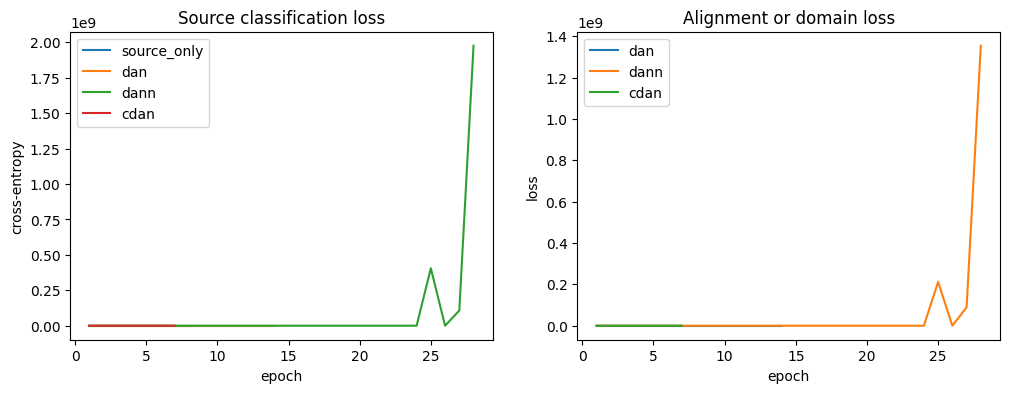

In [14]:
# Save curves as machine-readable values and display both loss components.
for method, history in histories.items():
    pd.DataFrame(history).to_csv(RESULTS / f"{method}_history.csv", index=False)
if CONFIG["print_metrics"]:
    final_epochs = [{"method": method, **history[-1]} for method, history in histories.items()]
    print("Last training epoch for each method; full curves are saved to CSV")
    display(pd.DataFrame(final_epochs).round(4))
if CONFIG["plot"]:
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    for method, history in histories.items():
        epochs = [item["epoch"] for item in history]
        axes[0].plot(epochs, [item["classification_loss"] for item in history], label=method)
        if method != "source_only":
            axes[1].plot(
                epochs, [item["alignment_or_domain_loss"] for item in history], label=method
            )
    axes[0].set(title="Source classification loss", xlabel="epoch", ylabel="cross-entropy")
    axes[1].set(title="Alignment or domain loss", xlabel="epoch", ylabel="loss")
    axes[0].legend()
    axes[1].legend()
    figure.savefig(REPO_RESULTS_DIR / "training_losses.png", dpi=150, bbox_inches="tight")
    plt.show()
